In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_FO = pd.read_csv("../FO_videos/landmarks_unnormalised_with_angles_clean.csv")
df_DTL = pd.read_csv("../DTL_frames/landmarks_unnormalised_with_angles_clean.csv")
df_coach = pd.read_csv("../FO_videos/standard_angles.csv")

# Combine both datasets
df_all = pd.concat([df_FO, df_DTL], ignore_index=True)

# Ensure consistent Position order
positions_order = sorted(df_all["Position"].unique(), key=lambda x: int(x[1:]))
df_all["Position"] = pd.Categorical(df_all["Position"], categories=positions_order, ordered=True)
df_coach["Position"] = pd.Categorical(df_coach["Position"], categories=positions_order, ordered=True)

df_all

,Unnamed: 0,Frame_Name,Person,Camera_Angle,Frame_Number,Position,shoulder_tilt_deg,hip_tilt_deg,shoulder_rotation_deg,hip_rotation_deg,forward_tilt_deg,lead_arm_deg,knee_bend_deg
0,0,eric_1_frame27.jpg,eric_1,FO,frame27,P1,8.462072,0.495341,15.049882,16.201505,74.812820,176.564132,172.245353
1,1,grant_frame84.jpg,grant,FO,frame84,P1,9.983776,2.123441,13.029372,21.986555,72.661403,170.222348,164.731959
2,2,jess_1_frame93.jpg,jess_1,FO,frame93,P1,8.267206,3.696810,19.000035,14.227823,74.970642,173.401931,168.171638
3,3,jess_2_frame200.jpg,jess_2,FO,frame200,P1,4.919528,1.675489,8.154969,9.402055,74.122393,174.128739,170.259089
4,4,nick_1_frame18.jpg,nick_1,FO,frame18,P1,12.473958,1.960629,5.087098,7.743757,69.015402,177.465753,164.664866
...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,400,tom_DTL_2_frame46.jpg,tom_DTL_2,DTL,frame46,P10,28.239687,15.386374,42.577308,3.614665,22.984610,41.407433,176.255593
544,401,tom_DTL_2_frame47.jpg,tom_DTL_2,DTL,frame47,P10,25.057718,14.180205,58.605052,37.018420,21.642033,50.662408,178.324793
545,402,tom_DTL_2_frame48.jpg,tom_DTL_2,DTL,frame48,P10,23.589274,13.482080,54.750172,33.445543,20.693346,53.966273,179.653356
546,403,tom_DTL_2_frame49.jpg,tom_DTL_2,DTL,frame49,P10,21.048784,13.229790,51.353984,10.318760,20.429081,58.416121,179.483880


In [24]:
def remove_outliers_iqr(df, group_cols, angle_cols):
    df_filtered = []
    for keys, group in df.groupby(group_cols):
        g = group.copy()
        for angle in angle_cols:
            q1 = g[angle].quantile(0.25)
            q3 = g[angle].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            g = g[(g[angle] >= lower) & (g[angle] <= upper)]
        df_filtered.append(g)
    return pd.concat(df_filtered, ignore_index=True)

angle_cols = [
    "shoulder_tilt_deg", "hip_tilt_deg",
    "shoulder_rotation_deg", "hip_rotation_deg",
    "forward_tilt_deg", "lead_arm_deg", "knee_bend_deg"
]

df_all_filtered = remove_outliers_iqr(
    df_all, group_cols=["Position", "Camera_Angle"], angle_cols=angle_cols
)
df_all_filtered


C:\Users\cryst\AppData\Local\Temp\ipykernel_51524\2647880074.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for keys, group in df.groupby(group_cols):


,Unnamed: 0,Frame_Name,Person,Camera_Angle,Frame_Number,Position,shoulder_tilt_deg,hip_tilt_deg,shoulder_rotation_deg,hip_rotation_deg,forward_tilt_deg,lead_arm_deg,knee_bend_deg
0,0,eric_DTL_1_frame0.jpg,eric_DTL_1,DTL,frame0,P1,15.339738,3.616193,87.832446,83.582806,29.226593,177.353974,159.032212
1,1,eric_DTL_1_frame1.jpg,eric_DTL_1,DTL,frame1,P1,14.872318,3.314035,88.168022,84.561865,30.073246,178.616822,158.949527
2,2,eric_DTL_1_frame2.jpg,eric_DTL_1,DTL,frame2,P1,11.151093,1.671229,88.154952,84.753724,30.456134,179.175144,158.755142
3,3,eric_DTL_1_frame3.jpg,eric_DTL_1,DTL,frame3,P1,2.660642,0.560818,87.668090,84.490491,30.309499,177.542064,158.713616
4,4,eric_DTL_1_frame4.jpg,eric_DTL_1,DTL,frame4,P1,1.229292,0.400833,86.227771,83.821605,29.869984,173.882252,156.837381
...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,137,rob_1d_frame326.jpg,rob_1d,FO,frame326,P10,9.978014,7.568743,89.657677,86.156238,2.884446,138.375490,170.499859
409,138,rob_1e_frame418.jpg,rob_1e,FO,frame418,P10,17.295610,6.828628,85.510118,85.208991,24.425959,160.921215,168.032587
410,139,rob_2_frame88.jpg,rob_2,FO,frame88,P10,30.995158,21.621634,88.736217,86.983081,3.566447,168.494914,168.218023
411,140,tom_1_frame83.jpg,tom_1,FO,frame83,P10,8.429179,3.234227,88.238374,85.409469,10.419271,65.312105,175.883661


In [25]:
# Compute summary per position and camera angle, including mean, std, min, max, median
summary = (
    df_all_filtered
    .groupby(["Position", "Camera_Angle"])[
        angle_cols
    ]
    .agg(["mean", "std", "min", "max", "median"])
    .reset_index()
)

# Flatten the multi-index column names
summary.columns = ["Position", "Camera_Angle"] + [
    f"{col[0]}_{col[1]}" for col in summary.columns[2:]
]

summary

C:\Users\cryst\AppData\Local\Temp\ipykernel_51524\1450593110.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Position", "Camera_Angle"])[


,Position,Camera_Angle,shoulder_tilt_deg_mean,shoulder_tilt_deg_std,shoulder_tilt_deg_min,shoulder_tilt_deg_max,shoulder_tilt_deg_median,hip_tilt_deg_mean,hip_tilt_deg_std,hip_tilt_deg_min,...,lead_arm_deg_mean,lead_arm_deg_std,lead_arm_deg_min,lead_arm_deg_max,lead_arm_deg_median,knee_bend_deg_mean,knee_bend_deg_std,knee_bend_deg_min,knee_bend_deg_max,knee_bend_deg_median
0,P1,DTL,23.891258,16.192663,0.404167,62.687426,27.538506,5.634115,4.969010,0.149716,...,170.048966,6.949833,151.928156,179.739650,171.144891,156.468574,6.230638,142.809021,167.684033,157.858905
1,P1,FO,7.410832,2.099187,3.522581,10.837913,7.505523,3.225769,1.234564,0.495341,...,175.718795,3.091039,170.222348,179.646998,176.564132,172.368452,4.294117,164.731959,177.773694,171.501512
2,P2,DTL,26.647978,10.104436,4.880348,37.564374,30.753495,12.272893,5.287062,1.758388,...,172.295972,3.741761,165.478614,179.845146,171.940453,150.503327,4.967487,137.833033,159.354073,150.901740
3,P2,FO,12.858505,4.379569,8.562556,22.553269,11.535159,1.339142,1.360235,0.029654,...,157.160496,7.175931,147.435372,169.329788,157.136753,173.243574,6.569861,160.996766,179.981871,174.326120
4,P3,DTL,35.864187,4.533423,28.187750,42.778448,36.845687,17.361671,2.966577,12.093987,...,137.394553,18.090491,96.493718,168.786543,139.049969,141.246072,7.515647,123.918243,157.631875,142.609509
5,P3,FO,13.056094,7.875724,1.969913,27.562653,13.642778,4.049939,1.407276,2.452458,...,138.672555,11.839227,120.639986,157.544267,140.936476,176.100221,1.653741,172.992729,178.648345,176.303575
6,P4,DTL,35.102614,5.367448,25.665328,42.067596,34.729828,16.766029,3.240642,11.786983,...,143.923089,17.441465,114.298918,177.323928,141.835460,136.557276,8.336977,118.548377,146.037969,140.044582
7,P4,FO,3.672345,3.649710,0.086231,11.823428,2.414513,2.789664,1.444035,0.785130,...,123.855684,13.353177,101.937187,137.300208,129.721208,169.918329,5.151052,162.221146,178.088320,168.537537
8,P5,DTL,34.624846,5.322239,21.703701,41.227829,35.914086,15.575285,1.507356,11.962740,...,137.640917,27.775495,71.655283,176.390559,138.306352,143.796621,4.679186,135.241532,151.636541,143.213410
9,P5,FO,10.438641,6.325997,4.807088,22.781796,7.978711,4.726546,0.980810,3.339862,...,141.282314,11.407072,122.858654,157.447917,137.086441,171.467848,8.757814,156.802697,178.835760,176.677074


C:\Users\cryst\AppData\Local\Temp\ipykernel_51524\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


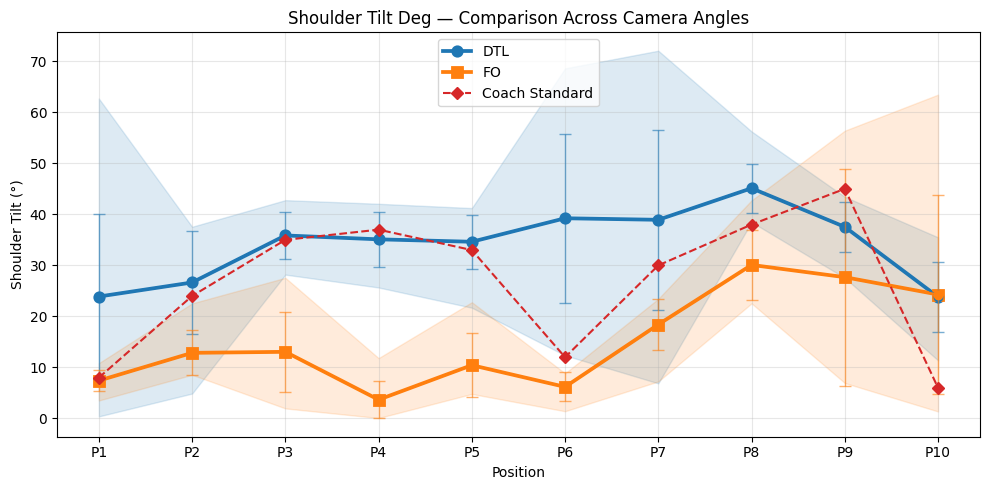

C:\Users\cryst\AppData\Local\Temp\ipykernel_51524\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


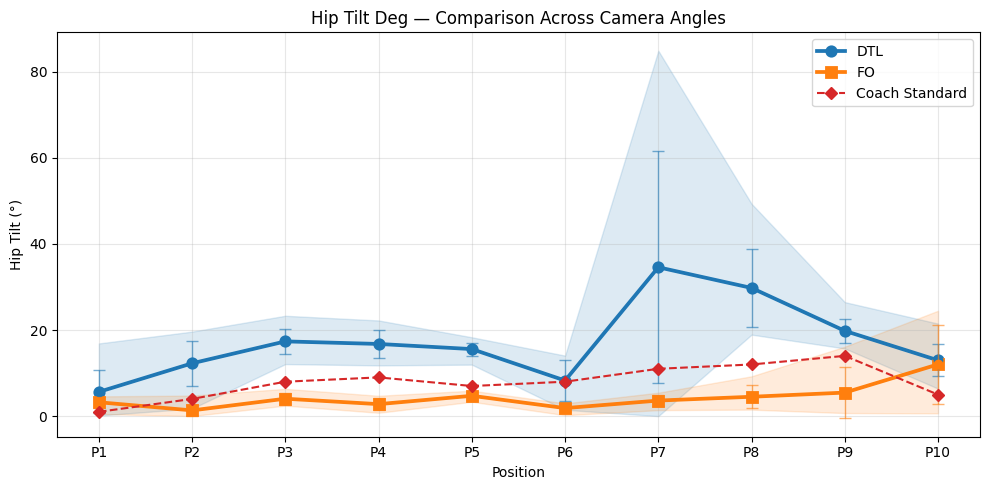

C:\Users\cryst\AppData\Local\Temp\ipykernel_51524\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


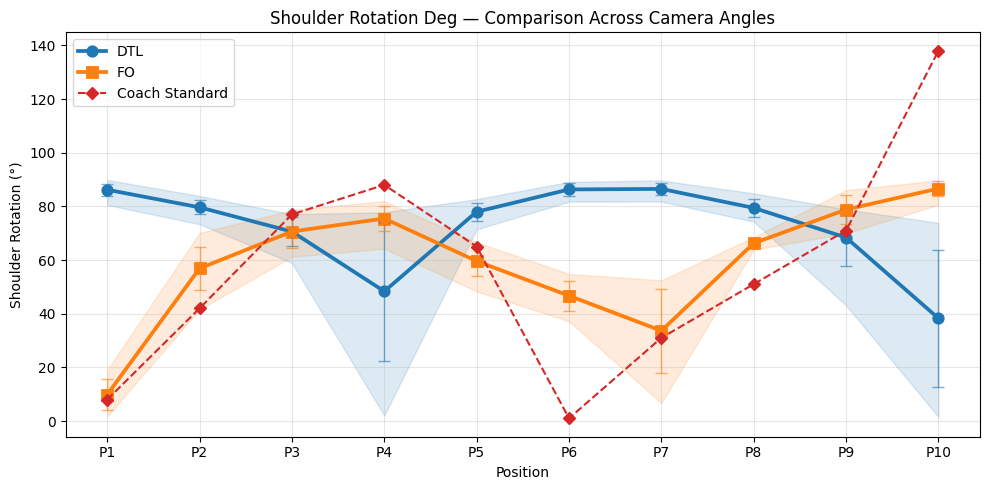

C:\Users\cryst\AppData\Local\Temp\ipykernel_51524\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


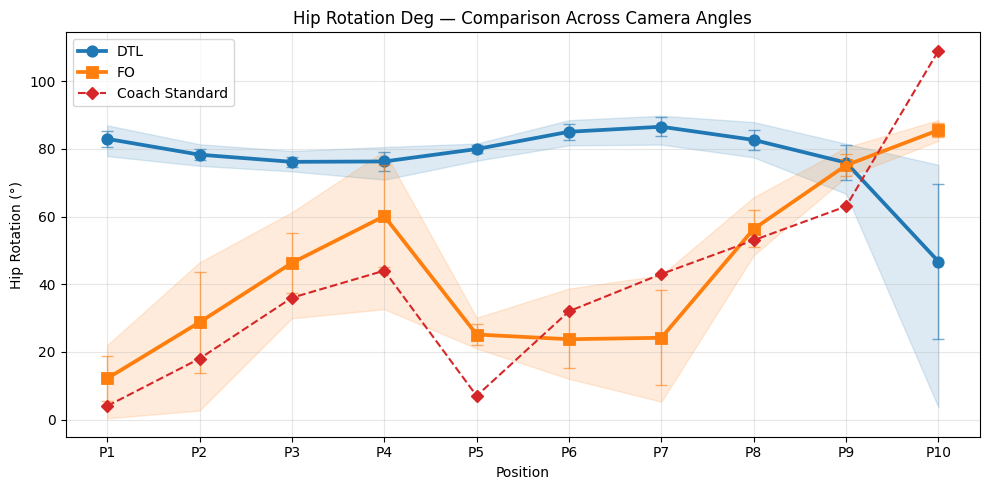

In [26]:
def plot_angle_comparison_by_camera(angle_name, ylabel=None):
    plt.figure(figsize=(10, 5))

    # Define color palette
    palette = sns.color_palette("tab10")
    camera_angles = summary["Camera_Angle"].unique()
    color_map = {cam: palette[i % len(palette)] for i, cam in enumerate(camera_angles)}

    # Plot mean lines
    sns.pointplot(
        data=summary,
        x="Position",
        y=f"{angle_name}_mean",
        hue="Camera_Angle",
        join=True,
        markers=["o", "s", "D"],
        palette=color_map,
        dodge=False
    )

    # Add per-camera shading and error bars
    for camera in camera_angles:
        subset = summary[summary["Camera_Angle"] == camera]

        plt.plot(
            subset["Position"],
            subset[f"{angle_name}_mean"],
            color=color_map[camera],
            marker="o",
        )

        plt.fill_between(
            subset["Position"],
            subset[f"{angle_name}_min"],
            subset[f"{angle_name}_max"],
            color=color_map[camera],
            alpha=0.15,
            label=None
        )

        plt.errorbar(
            subset["Position"],
            subset[f"{angle_name}_mean"],
            yerr=subset[f"{angle_name}_std"],
            fmt="none",
            ecolor=color_map[camera],
            elinewidth=1,
            alpha=0.6,
            capsize=4
        )

    # Try to plot coach benchmark if available
    coach_col = f"{angle_name.replace('_deg', '_standard')}"
    if coach_col in df_coach.columns:
        plt.plot(
            df_coach["Position"],
            df_coach[coach_col],
            color="tab:red",
            linestyle="--",
            marker="D",
            label="Coach Standard"
        )

    # Plot formatting
    plt.title(f"{angle_name.replace('_', ' ').title()} — Comparison Across Camera Angles")
    plt.xlabel("Position")
    plt.ylabel(ylabel or "Angle (°)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_angle_comparison_by_camera("shoulder_tilt_deg", "Shoulder Tilt (°)")
plot_angle_comparison_by_camera("hip_tilt_deg", "Hip Tilt (°)")
plot_angle_comparison_by_camera("shoulder_rotation_deg", "Shoulder Rotation (°)")
plot_angle_comparison_by_camera("hip_rotation_deg", "Hip Rotation (°)")

In [27]:
recommendations = []

for angle in ["shoulder_tilt_deg", "hip_tilt_deg", "shoulder_rotation_deg", "hip_rotation_deg"]:
    coach_col = f"{angle.replace('_deg', '_standard')}"
    mean_col = f"{angle}_mean"
    std_col = f"{angle}_std"

    # Merge to get coach data
    merged = summary.merge(df_coach[["Position", coach_col]], on="Position", how="left")

    # Compute absolute difference
    merged[f"{angle}_abs_diff"] = abs(merged[mean_col] - merged[coach_col])

    # Identify positions where *both* camera angles deviate > 10°
    deviation_check = (
        merged.groupby("Position")[f"{angle}_abs_diff"]
        .apply(lambda x: (x > 10).all())
        .rename("both_far")
    )
    merged = merged.merge(deviation_check, on="Position", how="left")

    # --- Selection logic ---
    best_rows = []
    for pos, group in merged.groupby("Position", sort=False):
        if group["both_far"].iloc[0]:
            # Both cameras too far → choose lowest variation (std)
            if std_col in group.columns and group[std_col].notna().any():
                chosen = group.loc[group[std_col].idxmin()]
            else:
                chosen = group.loc[group[f"{angle}_abs_diff"].idxmin()]
        else:
            # Normal case → choose closest to coach
            chosen = group.loc[group[f"{angle}_abs_diff"].idxmin()]
        best_rows.append(chosen)

    best = (
        pd.DataFrame(best_rows)[["Position", "Camera_Angle", f"{angle}_abs_diff"]]
        .rename(columns={
            "Camera_Angle": f"{angle}_best_camera",
            f"{angle}_abs_diff": f"{angle}_min_diff"
        })
    )

    recommendations.append(best)

# Combine all angles
camera_summary = recommendations[0]
for rec in recommendations[1:]:
    camera_summary = camera_summary.merge(rec, on="Position", how="outer")
camera_summary = (
    camera_summary
    .assign(
        pos_num=camera_summary["Position"].str.extract(r"(\d+)").astype(int)
    )
    .sort_values("pos_num")
    .drop(columns="pos_num")
    .reset_index(drop=True)
)

camera_summary


C:\Users\cryst\AppData\Local\Temp\ipykernel_51524\2647894012.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby("Position")[f"{angle}_abs_diff"]
C:\Users\cryst\AppData\Local\Temp\ipykernel_51524\2647894012.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, group in merged.groupby("Position", sort=False):
C:\Users\cryst\AppData\Local\Temp\ipykernel_51524\2647894012.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and 

,Position,shoulder_tilt_deg_best_camera,shoulder_tilt_deg_min_diff,hip_tilt_deg_best_camera,hip_tilt_deg_min_diff,shoulder_rotation_deg_best_camera,shoulder_rotation_deg_min_diff,hip_rotation_deg_best_camera,hip_rotation_deg_min_diff
0,P1,FO,0.589168,FO,2.225769,FO,1.847603,FO,8.145878
1,P2,DTL,2.647978,FO,2.660858,DTL,37.637142,DTL,60.274221
2,P3,DTL,0.864187,FO,3.950061,FO,6.379316,DTL,40.158578
3,P4,DTL,1.897386,FO,6.210336,FO,12.531164,DTL,32.271938
4,P5,DTL,1.624846,FO,2.273454,FO,5.405158,DTL,72.941264
5,P6,FO,5.814790,DTL,0.269187,DTL,85.303317,FO,8.264652
6,P7,DTL,8.929662,FO,7.379961,FO,2.637775,DTL,43.534096
7,P8,DTL,7.112977,FO,7.495166,FO,15.265725,FO,3.329598
8,P9,DTL,7.460616,DTL,5.802016,DTL,2.637894,FO,12.144640
9,P10,DTL,17.816235,FO,7.025089,FO,51.368791,FO,23.472570


In [28]:
# --- Compute Z-index (standardized deviation from coach standard) ---
z_index_table = []

for angle in ["shoulder_tilt_deg", "hip_tilt_deg", "shoulder_rotation_deg", "hip_rotation_deg"]:
    coach_col = f"{angle.replace('_deg', '_standard')}"
    mean_col = f"{angle}_mean"
    std_col = f"{angle}_std"

    if std_col not in summary.columns:
        print(f"Skipping {angle}: no standard deviation column found.")
        continue

    # Merge coach standard
    merged = summary.merge(df_coach[["Position", coach_col]], on="Position", how="left")

    # Calculate Z-index for each camera (how many std devs the mean differs from coach)
    merged[f"{angle}_z_index"] = (merged[mean_col] - merged[coach_col]) / merged[std_col]

    # Keep key columns only
    z_index_table.append(
        merged[["Position", "Camera_Angle", f"{angle}_z_index"]]
    )

# Combine all Z-indexes into one wide table
z_index_summary = z_index_table[0]
for rec in z_index_table[1:]:
    z_index_summary = z_index_summary.merge(rec, on=["Position", "Camera_Angle"], how="outer")

z_index_summary = (
    z_index_summary
    .assign(pos_num=z_index_summary["Position"].str.extract(r"(\d+)").astype(int))
    .sort_values("pos_num")
    .drop(columns="pos_num")
    .reset_index(drop=True)
)

z_index_summary


,Position,Camera_Angle,shoulder_tilt_deg_z_index,hip_tilt_deg_z_index,shoulder_rotation_deg_z_index,hip_rotation_deg_z_index
0,P1,DTL,0.981386,0.932603,34.157863,34.195913
1,P1,FO,-0.280665,1.802880,0.313003,1.247447
2,P2,DTL,0.262061,1.564743,14.454237,39.307671
3,P2,FO,-2.543971,-1.956175,1.865094,0.719759
4,P3,DTL,0.190626,3.155715,-1.197114,27.900450
5,P3,FO,-2.786272,-2.806884,-1.059661,1.171753
6,P4,DTL,-0.353499,2.396447,-1.524880,11.210179
7,P4,FO,-9.131591,-4.300684,-2.591222,1.069370
8,P5,FO,-3.566451,-2.317935,-0.987454,5.656597
9,P5,DTL,0.305294,5.688959,3.872152,58.661869


In [29]:
display_cols = [
    "Position",
    "shoulder_tilt_deg_best_camera",
    "hip_tilt_deg_best_camera",
    "shoulder_rotation_deg_best_camera",
    "hip_rotation_deg_best_camera"
]
camera_summary[display_cols]

,Position,shoulder_tilt_deg_best_camera,hip_tilt_deg_best_camera,shoulder_rotation_deg_best_camera,hip_rotation_deg_best_camera
0,P1,FO,FO,FO,FO
1,P2,DTL,FO,DTL,DTL
2,P3,DTL,FO,FO,DTL
3,P4,DTL,FO,FO,DTL
4,P5,DTL,FO,FO,DTL
5,P6,FO,DTL,DTL,FO
6,P7,DTL,FO,FO,DTL
7,P8,DTL,FO,FO,FO
8,P9,DTL,DTL,DTL,FO
9,P10,DTL,FO,FO,FO


# Computing other angle values

C:\Users\cryst\AppData\Local\Temp\ipykernel_51524\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


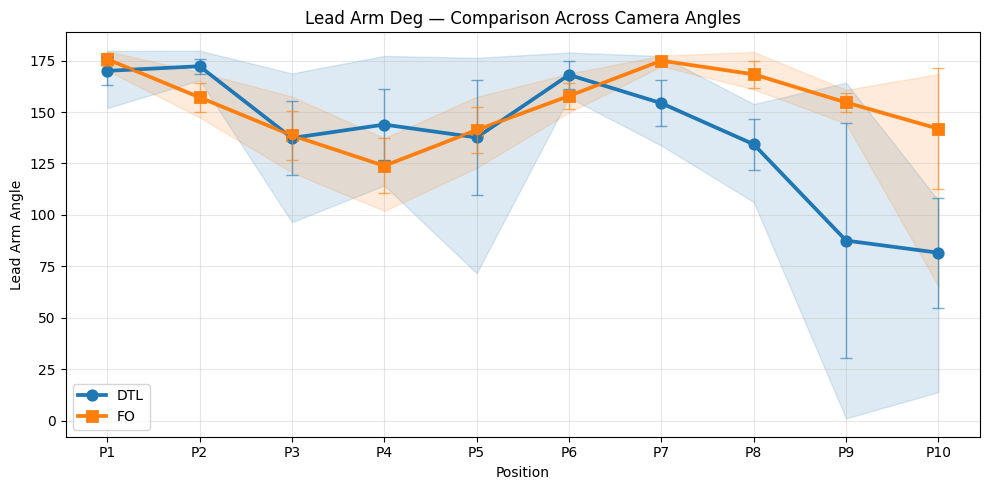

C:\Users\cryst\AppData\Local\Temp\ipykernel_51524\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


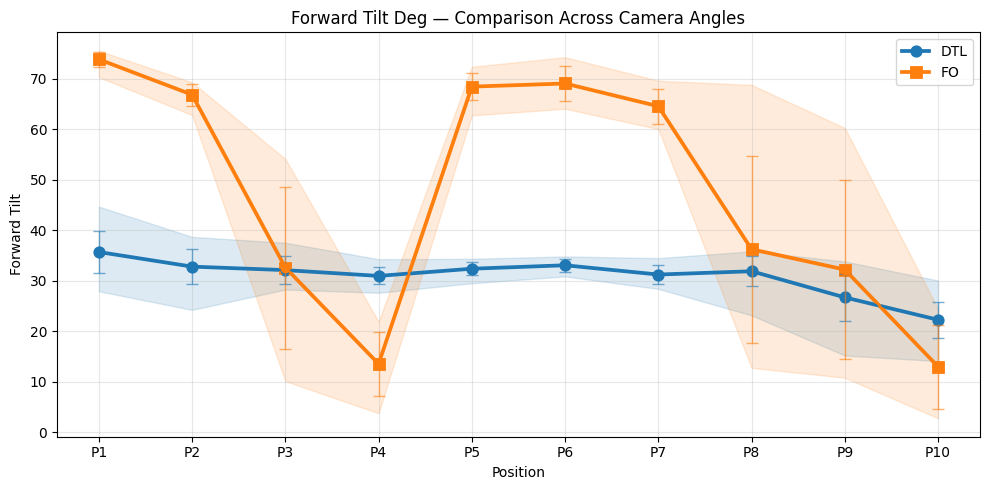

C:\Users\cryst\AppData\Local\Temp\ipykernel_51524\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


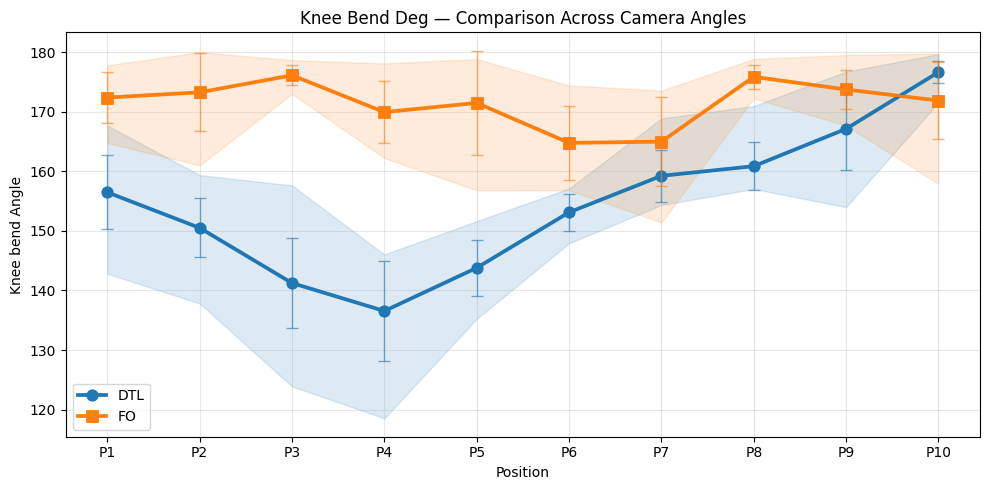

In [30]:
plot_angle_comparison_by_camera("lead_arm_deg", "Lead Arm Angle")
plot_angle_comparison_by_camera("forward_tilt_deg", "Forward Tilt")
plot_angle_comparison_by_camera("knee_bend_deg", "Knee bend Angle")